# Jerk-GNN: Learning Spring-Mass Dynamics via Explicit Jerk Modeling

## Problem
Predict the dynamics of a physical system where only **position** $x$ is observed. A 6-body spring-mass system serves as a synthetic testbed where ground truth is available for validation.

## Core Idea
Rather than predicting position or acceleration directly, we predict **jerk** $j_i = \dddot{x}_i$ — the third derivative of position. Acceleration, velocity, and next position are then derived **analytically** via a constant-jerk Taylor expansion (hard consistency). This means the network has a single, physically interpretable output.

### Integration Scheme (O(dt⁴) truncation error)
$$x(t+dt) = x(t) + v(t)\,dt + \tfrac{1}{2}a(t)\,dt^2 + \tfrac{1}{6}j(t)\,dt^3$$
$$v(t+dt) = v(t) + a(t)\,dt + \tfrac{1}{2}j(t)\,dt^2$$
$$a(t+dt) = a(t) + j(t)\,dt$$

## Why a GNN?
The true jerk for mass $i$ is $j_i = \frac{1}{m_i}\sum_j k_{ij}(v_j - v_i)$ — a **sum over neighbors**. This is exactly the operation a GNN's message-passing implements, making the architecture a natural fit. Learned edge weights are implicit proxies for unknown spring constants.

## Notebook Contents
1. Simulate spring-mass system & visualize topology  
2. Build dataset with finite-difference $v$, $a$ estimates  
3. GNN architecture (JerkMessagePassing + hard consistency)  
4. Training (single-step MSE, Adam + cosine LR)  
5. Training curves  
6. Rollout: position, velocity, phase portraits  
7. Jerk correlation: predicted vs analytic  
8. Error over time & energy conservation

In [60]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from torch_geometric.nn import MessagePassing
from torch_geometric.data import Data, DataLoader
from scipy.integrate import solve_ivp

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 1. Simulate Spring-Mass System

### Equations of Motion
For $n$ masses connected by springs in 1D:
$$m_i \ddot{x}_i = \sum_j k_{ij}\bigl[(x_j - x_i) - \text{sign}(j-i)\,\ell_{ij}\bigr]$$

where $k_{ij}$ is the spring constant and $\ell_{ij}$ is the natural length between bodies $i$ and $j$.

### Analytic Jerk
Differentiating the equation of motion with respect to time:
$$j_i = \dddot{x}_i = \frac{\dot{F}_i}{m_i} = \frac{1}{m_i}\sum_j k_{ij}(v_j - v_i)$$

This is the **supervision signal** we use — directly computable from the simulation's velocity output.

### Synthetic System Parameters
- $n = 6$ bodies, masses drawn uniformly from $[0.5, 2.0]$
- Spring connectivity: 60% random + chain backbone (no isolated nodes)
- Spring constants $k_{ij} \in [0.5, 3.0]$, natural lengths $\ell_{ij} \approx |i-j|$
- Trajectories integrated with RK45 (rtol=1e-8)

In [61]:
class SpringMassSystem:
    """
    N bodies connected by springs in 1D.
    
    Equation of motion:
        m_i * a_i = sum_j k_ij * (x_j - x_i - l_ij)
    
    Analytic jerk:
        j_i = (1/m_i) * sum_j k_ij * (v_j - v_i)
    """
    def __init__(self, n_bodies=6, seed=42):
        rng = np.random.default_rng(seed)
        self.n = n_bodies
        
        # masses
        self.masses = rng.uniform(0.5, 2.0, n_bodies)
        
        # spring constants — sparse random connectivity
        K = np.zeros((n_bodies, n_bodies))
        for i in range(n_bodies):
            for j in range(i+1, n_bodies):
                if rng.random() < 0.6:  # 60% connectivity
                    k = rng.uniform(0.5, 3.0)
                    K[i, j] = k
                    K[j, i] = k
        # ensure chain connectivity so no isolated nodes
        for i in range(n_bodies - 1):
            if K[i, i+1] == 0:
                k = rng.uniform(0.5, 3.0)
                K[i, i+1] = k
                K[i+1, i] = k
        self.K = K
        
        # natural lengths — slightly randomised around equilibrium spacing
        L = np.zeros((n_bodies, n_bodies))
        for i in range(n_bodies):
            for j in range(n_bodies):
                if K[i, j] > 0:
                    L[i, j] = abs(i - j) + rng.uniform(-0.1, 0.1)
        self.L = L
        
        # edge index for GNN (directed both ways)
        edges = [(i, j) for i in range(n_bodies)
                         for j in range(n_bodies) if K[i, j] > 0]
        self.edge_index = torch.tensor(edges, dtype=torch.long).T  # (2, E)
        self.edge_attr  = torch.tensor(
            [K[i, j] for i, j in edges], dtype=torch.float32
        ).unsqueeze(1)  # (E, 1)

    def ode(self, t, state):
        x = state[:self.n]
        v = state[self.n:]
        a = np.zeros(self.n)
        for i in range(self.n):
            for j in range(self.n):
                if self.K[i, j] > 0:
                    disp = (x[j] - x[i]) - np.sign(j - i) * self.L[i, j]
                    a[i] += self.K[i, j] * disp / self.masses[i]
        return np.concatenate([v, a])

    def analytic_jerk(self, v):
        """True jerk: j_i = (1/m_i) * sum_j k_ij*(v_j - v_i)"""
        j = np.zeros(self.n)
        for i in range(self.n):
            for jj in range(self.n):
                if self.K[i, jj] > 0:
                    j[i] += self.K[i, jj] * (v[jj] - v[i]) / self.masses[i]
        return j

    def simulate(self, T=20.0, dt=0.05, x0=None, v0=None):
        rng = np.random.default_rng()
        if x0 is None:
            x0 = np.arange(self.n, dtype=float) + rng.uniform(-0.3, 0.3, self.n)
        if v0 is None:
            v0 = rng.uniform(-1.0, 1.0, self.n)
        
        t_span = (0, T)
        t_eval = np.arange(0, T, dt)
        sol = solve_ivp(self.ode, t_span, np.concatenate([x0, v0]),
                        t_eval=t_eval, method='RK45', rtol=1e-8, atol=1e-10)
        
        x_traj = sol.y[:self.n].T   # (T, n)
        v_traj = sol.y[self.n:].T   # (T, n)
        return x_traj, v_traj, t_eval


system = SpringMassSystem(n_bodies=6)
print(f'Spring constant matrix K:\n{np.round(system.K, 2)}')
print(f'Mass vector: {np.round(system.masses, 2)}')
print(f'Number of spring connections: {system.edge_index.shape[1]}')

Spring constant matrix K:
[[0.   0.61 0.   1.63 2.82 0.  ]
 [0.61 0.   0.89 1.07 0.66 0.  ]
 [0.   0.89 0.   2.21 0.   2.93]
 [1.63 1.07 2.21 0.   2.36 0.  ]
 [2.82 0.66 0.   2.36 0.   1.67]
 [0.   0.   2.93 0.   1.67 0.  ]]
Mass vector: [1.66 1.16 1.79 1.55 0.64 1.96]
Number of spring connections: 20


### System topology

The graph below shows the spring network. Node size encodes mass; edge width and color encode spring constant strength. This topology is fixed across all trajectories — the GNN sees it via edge attributes.

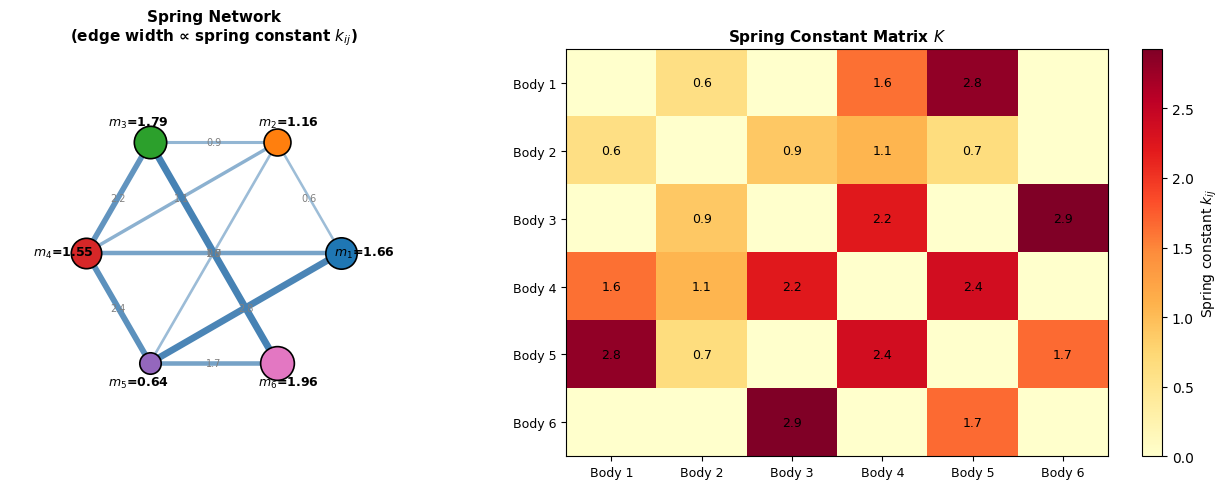

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: spring graph ────────────────────────────────────────────────────────
ax = axes[0]
n = system.n
# lay bodies on a circle
angles = np.linspace(0, 2 * np.pi, n, endpoint=False)
pos = np.stack([np.cos(angles), np.sin(angles)], axis=1)

k_max = system.K.max()
for i in range(n):
    for j in range(i + 1, n):
        if system.K[i, j] > 0:
            lw = 1 + 4 * system.K[i, j] / k_max
            alpha = 0.4 + 0.6 * system.K[i, j] / k_max
            ax.plot([pos[i, 0], pos[j, 0]], [pos[i, 1], pos[j, 1]],
                    color='steelblue', linewidth=lw, alpha=alpha, zorder=1)
            mid = (pos[i] + pos[j]) / 2
            ax.text(mid[0], mid[1], f'{system.K[i,j]:.1f}',
                    fontsize=7, ha='center', va='center', color='gray')

colors6 = plt.cm.tab10(np.linspace(0, 0.6, n))
for i in range(n):
    sz = 200 + 400 * (system.masses[i] - 0.5) / 1.5
    ax.scatter(*pos[i], s=sz, color=colors6[i], zorder=3, edgecolors='k', linewidth=1.2)
    ax.text(pos[i, 0] * 1.18, pos[i, 1] * 1.18,
            f'$m_{i+1}$={system.masses[i]:.2f}', fontsize=9,
            ha='center', va='center', fontweight='bold')

ax.set_xlim(-1.6, 1.6)
ax.set_ylim(-1.6, 1.6)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Spring Network\n(edge width ∝ spring constant $k_{ij}$)', fontsize=11, fontweight='bold')

# ── Right: spring constant matrix heatmap ────────────────────────────────────
ax2 = axes[1]
im = ax2.imshow(system.K, cmap='YlOrRd', aspect='auto')
plt.colorbar(im, ax=ax2, label='Spring constant $k_{ij}$')
for i in range(n):
    for j in range(n):
        if system.K[i, j] > 0:
            ax2.text(j, i, f'{system.K[i,j]:.1f}', ha='center', va='center',
                     fontsize=9, color='black')
ax2.set_xticks(range(n))
ax2.set_yticks(range(n))
ax2.set_xticklabels([f'Body {i+1}' for i in range(n)], fontsize=9)
ax2.set_yticklabels([f'Body {i+1}' for i in range(n)], fontsize=9)
ax2.set_title('Spring Constant Matrix $K$', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('/projectnb/depaqlab/bddepasq/spring-mass/png/topo-plot.png', dpi=150, bbox_inches='tight')
plt.show()

In [63]:
# Simulate training trajectories
DT = 0.05
N_TRAJ_TRAIN = 40
N_TRAJ_TEST  = 10
T_TRAIN = 15.0
T_TEST  = 20.0
HISTORY = 5   # steps of x history fed to GNN
JERK_WEIGHT = 1.0  # weight on jerk supervision loss

def finite_diff_va(x_traj, dt):
    """Estimate v and a from position trajectory via finite differences."""
    v = np.gradient(x_traj, dt, axis=0)
    a = np.gradient(v, dt, axis=0)
    return v, a

def build_dataset(system, n_traj, T, dt, history_len):
    dataset = []
    for _ in range(n_traj):
        x_traj, v_traj, t_eval = system.simulate(T=T, dt=dt)
        _, a_traj = finite_diff_va(x_traj, dt)

        T_steps = x_traj.shape[0]
        for t in range(history_len, T_steps - 1):
            x_hist    = torch.tensor(x_traj[t-history_len:t].T, dtype=torch.float32)  # (n, history)
            a0        = torch.tensor(a_traj[t],   dtype=torch.float32)  # (n,)
            v0        = torch.tensor(v_traj[t],   dtype=torch.float32)  # (n,)
            x_target  = torch.tensor(x_traj[t+1], dtype=torch.float32)  # (n,)
            j_target  = torch.tensor(system.analytic_jerk(v_traj[t]), dtype=torch.float32)  # (n,)

            dataset.append((x_hist, a0, v0, x_target, j_target))
    return dataset

print('Simulating training data...')
train_data = build_dataset(system, N_TRAJ_TRAIN, T_TRAIN, DT, HISTORY)
print('Simulating test data...')
test_data  = build_dataset(system, N_TRAJ_TEST,  T_TEST,  DT, HISTORY)
print(f'Train samples: {len(train_data)}, Test samples: {len(test_data)}')

Simulating training data...
Simulating test data...
Train samples: 11760, Test samples: 3940


### Sample Trajectory
One simulated trajectory — positions and velocities for all 6 bodies. These are generated with `scipy.integrate.solve_ivp` (RK45). Velocity and acceleration are estimated from position via finite differences for use as GNN inputs.

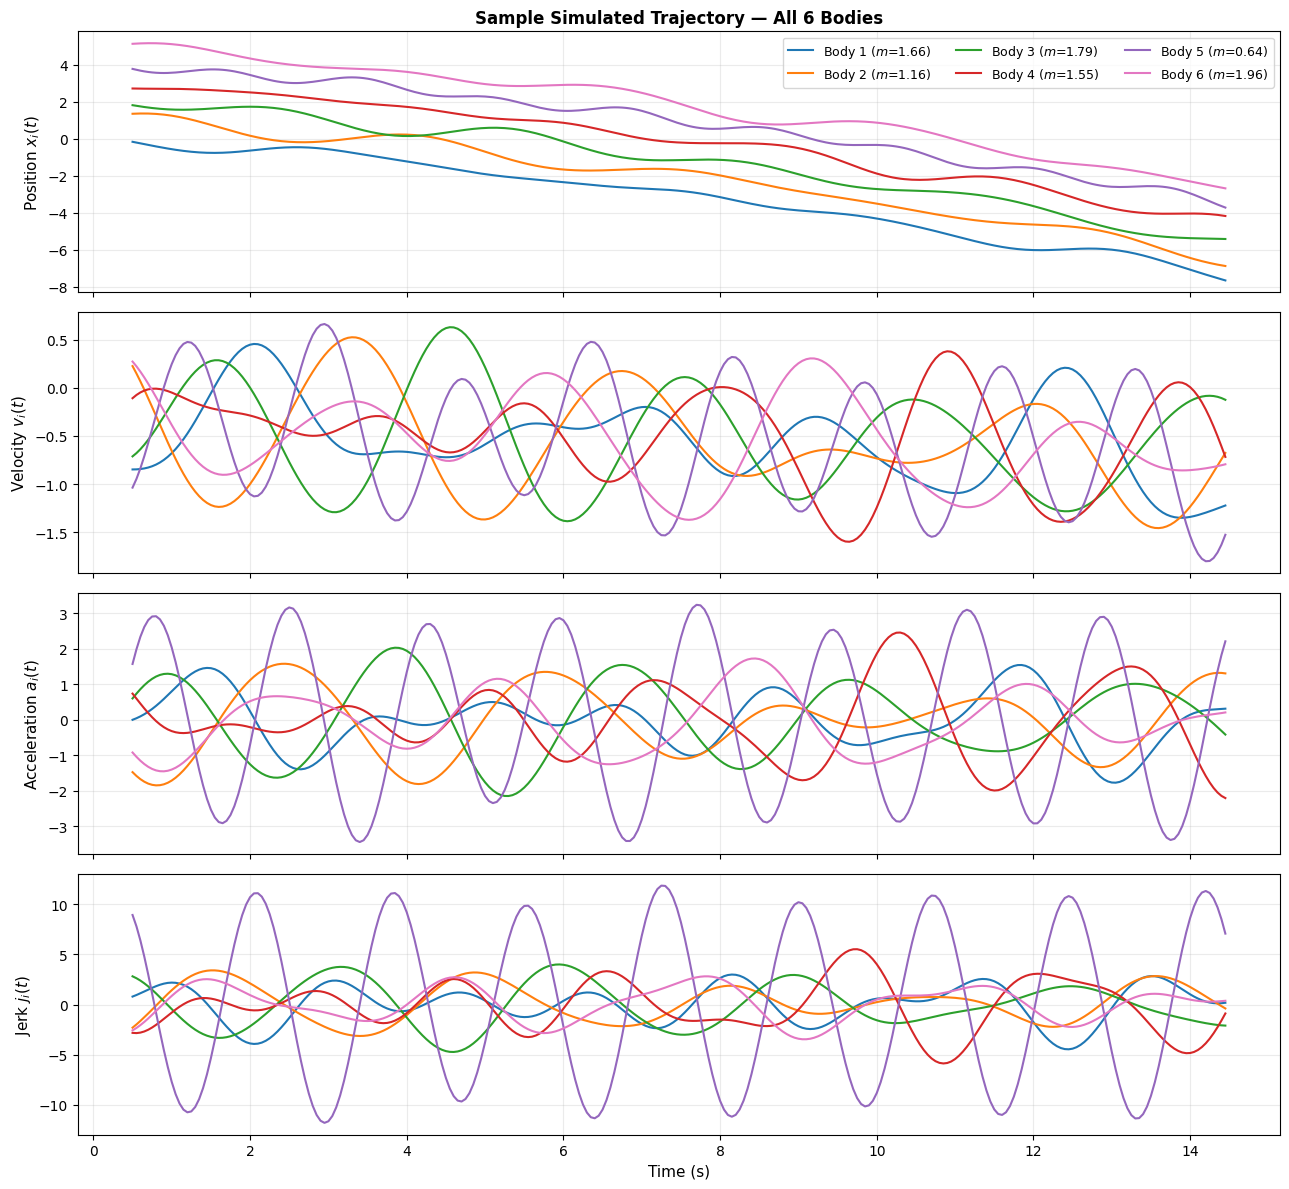

In [64]:
x_sample, v_sample, t_sample = system.simulate(T=15.0, dt=DT)
_, a_sample = finite_diff_va(x_sample, DT)
j_sample = np.array([system.analytic_jerk(v_sample[t]) for t in range(len(t_sample))])

TRIM_TRAJ = 10  # skip first/last steps to avoid FD boundary artifacts
sl = slice(TRIM_TRAJ, -TRIM_TRAJ)

fig, axes = plt.subplots(4, 1, figsize=(13, 12), sharex=True)
labels = ['Position $x_i(t)$', 'Velocity $v_i(t)$', 'Acceleration $a_i(t)$', 'Jerk $j_i(t)$']
data   = [x_sample, v_sample, a_sample, j_sample]

for row, (ax, dat, lbl) in enumerate(zip(axes, data, labels)):
    for i in range(6):
        kw = dict(label=f'Body {i+1} ($m$={system.masses[i]:.2f})') if row == 0 else {}
        ax.plot(t_sample[sl], dat[sl, i], color=colors6[i], linewidth=1.5, **kw)
    ax.set_ylabel(lbl, fontsize=11)
    ax.grid(True, alpha=0.25)

axes[0].legend(ncol=3, fontsize=9, loc='upper right')
axes[0].set_title('Sample Simulated Trajectory — All 6 Bodies', fontsize=12, fontweight='bold')
axes[-1].set_xlabel('Time (s)', fontsize=11)
plt.tight_layout()
plt.savefig('/projectnb/depaqlab/bddepasq/spring-mass/png/traj-plot.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. GNN Architecture

### Node features

Each node $i$ receives a feature vector:
$$\mathbf{h}_i^{(0)} = \text{Linear}\bigl([x_i(t-k),\,\ldots,\,x_i(t),\,v_i(t),\,a_i(t)]\bigr) \in \mathbb{R}^{d}$$

where $k=5$ is the history length, and $v_i$, $a_i$ are estimated by finite differences. The history window gives the network temporal context to infer velocity and acceleration trends without relying solely on noisy FD estimates.

### Message passing

At each of $L=3$ layers, messages from neighbor $j$ to node $i$ are computed as:
$$\mathbf{m}_{j \to i} = \phi_m\bigl([\mathbf{h}_i^{(\ell)},\, \mathbf{h}_j^{(\ell)},\, k_{ij}]\bigr)$$

Node states are updated with a residual connection:
$$\mathbf{h}_i^{(\ell+1)} = \mathbf{h}_i^{(\ell)} + \phi_u\!\left(\left[\mathbf{h}_i^{(\ell)},\, \sum_{j \in \mathcal{N}(i)} \mathbf{m}_{j \to i}\right]\right)$$

Both $\phi_m$ and $\phi_u$ are 2-layer MLPs with Tanh activations. The residual connection aids gradient flow and allows the network to represent near-identity updates.

### Output and hard consistency

A small MLP maps the final node embedding to a **scalar jerk** $\hat{j}_i$. The next state is then computed analytically:

$$\hat{x}(t+dt) = x + v\,dt + \tfrac{1}{2}a\,dt^2 + \tfrac{1}{6}\hat{j}\,dt^3$$

No additional learned parameters exist in the integration step — consistency between $x$, $v$, $a$ is guaranteed by construction.

### Why not predict acceleration directly?

| Approach | Predicted quantity | Integration order | Inductive bias |
|---|---|---|---|
| Neural ODE | $a$ | 2nd order (Verlet) | None |
| **Jerk-GNN** | $j$ | **3rd order** | $j$ depends on velocity differences — GNN message structure matches physics |

The GNN message passing mirrors the physical formula $j_i = (1/m_i)\sum_j k_{ij}(v_j - v_i)$: each message carries information about a neighbor's velocity, and the sum aggregates coupling forces.

In [65]:
class JerkMessagePassing(MessagePassing):
    """
    Message passing layer for jerk prediction.
    
    Message from j -> i: f(x_i_feat, x_j_feat, edge_attr)
    Aggregation: sum
    Update: g(x_i_feat, aggregated_message)
    """
    def __init__(self, node_dim, edge_dim, hidden_dim):
        super().__init__(aggr='sum')
        
        # message network
        self.message_net = nn.Sequential(
            nn.Linear(2 * node_dim + edge_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
        )
        
        # update network
        self.update_net = nn.Sequential(
            nn.Linear(node_dim + hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, node_dim),
            nn.Tanh(),
        )

    def forward(self, x, edge_index, edge_attr):
        return self.propagate(edge_index, x=x, edge_attr=edge_attr)

    def message(self, x_i, x_j, edge_attr):
        # x_i, x_j: (E, node_dim); edge_attr: (E, edge_dim)
        return self.message_net(torch.cat([x_i, x_j, edge_attr], dim=-1))

    def update(self, aggr_out, x):
        return self.update_net(torch.cat([x, aggr_out], dim=-1))


class JerkGNN(nn.Module):
    """
    GNN that predicts jerk j_i for each node, then integrates
    analytically (hard consistency) to get a, v, x_next.
    """
    def __init__(self, n_bodies, history_len, hidden_dim=64, n_layers=3):
        super().__init__()
        self.n = n_bodies
        
        # node feature dim: history positions + v0 + a0
        node_input_dim = history_len + 2
        edge_dim = 1  # spring constant (or 1 if unknown)
        
        # input projection
        self.input_proj = nn.Linear(node_input_dim, hidden_dim)
        
        # message passing layers
        self.layers = nn.ModuleList([
            JerkMessagePassing(hidden_dim, edge_dim, hidden_dim)
            for _ in range(n_layers)
        ])
        
        # output head: hidden -> jerk (scalar per node)
        self.jerk_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.Tanh(),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, x_hist, a0, v0, edge_index, edge_attr, dt):
        """
        x_hist:    (batch*n, history_len)
        a0, v0:    (batch*n,)
        edge_index: (2, E) — node indices within one graph
        edge_attr:  (E, 1)
        dt:        scalar
        """
        # build node features
        node_feat = torch.cat([
            x_hist,
            v0.unsqueeze(-1),
            a0.unsqueeze(-1)
        ], dim=-1)  # (batch*n, history+2)
        
        h = torch.tanh(self.input_proj(node_feat))  # (batch*n, hidden)
        
        for layer in self.layers:
            h = h + layer(h, edge_index, edge_attr)  # residual
        
        j = self.jerk_head(h).squeeze(-1)  # (batch*n,)
        
        # hard consistency integration
        x0 = x_hist[:, -1]  # current position
        a_next  = a0 + j * dt
        v_next  = v0 + a0 * dt + 0.5 * j * dt**2
        x_next  = x0 + v0 * dt + 0.5 * a0 * dt**2 + (1/6) * j * dt**3
        
        return x_next, a_next, v_next, j


model = JerkGNN(
    n_bodies=6,
    history_len=HISTORY,
    hidden_dim=64,
    n_layers=3
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f'Model parameters: {n_params:,}')

Model parameters: 77,313


## 3. Training

### Loss function

We minimize **single-step position MSE** over the training trajectories:

$$\mathcal{L} = \frac{1}{|\mathcal{D}|}\sum_{(t,\tau) \in \mathcal{D}} \|\hat{x}_{\tau}(t+dt) - x_{\tau}^{\text{true}}(t+dt)\|^2$$

Although we predict jerk, the gradient signal flows through the analytic integration directly to $\hat{j}$, so the network learns to produce jerks that yield accurate next-step positions.

### Optimization details

| Hyperparameter | Value |
|---|---|
| Optimizer | Adam |
| Learning rate | $10^{-3}$ (initial) |
| LR schedule | Cosine annealing to 0 |
| Batch size | 256 |
| Epochs | 100 |
| Gradient clipping | $\|\nabla\|_2 \leq 1.0$ |
| Training trajectories | 40 × 15 s |
| Test trajectories | 10 × 20 s |

### Batching strategy

Each sample is a single time step $(x_{\text{hist}}, v_0, a_0) \to x_{\text{next}}$. A batch of $B$ samples is constructed by tiling the edge index: node offsets are shifted by $i \cdot N$ for the $i$-th graph in the batch, creating a block-diagonal adjacency structure that `MessagePassing` handles natively.

In [66]:
def collate_batch(batch, system, device):
    """Stack samples and tile edge_index / edge_attr for batch."""
    B = len(batch)
    n = system.n

    x_hists, a0s, v0s, targets, j_targets = zip(*batch)

    x_hist   = torch.cat(x_hists, dim=0).to(device)    # (B*n, history)
    a0       = torch.cat(a0s).to(device)                # (B*n,)
    v0       = torch.cat(v0s).to(device)                # (B*n,)
    target   = torch.stack(targets).to(device)          # (B, n)
    j_target = torch.cat(j_targets).to(device)          # (B*n,)

    ei = system.edge_index
    ea = system.edge_attr
    edge_index = torch.cat([ei + i * n for i in range(B)], dim=1).to(device)
    edge_attr  = ea.repeat(B, 1).to(device)

    return x_hist, a0, v0, target, j_target, edge_index, edge_attr


def train(model, train_data, test_data, system,
          n_epochs=100, batch_size=256, lr=1e-3, jerk_weight=1.0):

    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, n_epochs)
    criterion = nn.MSELoss()

    train_losses, test_losses = [], []
    train_pos_losses, train_jerk_losses = [], []

    for epoch in range(n_epochs):
        model.train()
        epoch_loss = epoch_pos = epoch_jerk = 0

        idx = torch.randperm(len(train_data))
        batches = [list(idx[i:i+batch_size].numpy())
                   for i in range(0, len(train_data), batch_size)]

        for batch_idx in batches:
            batch = [train_data[i] for i in batch_idx]
            x_hist, a0, v0, target, j_target, edge_index, edge_attr = \
                collate_batch(batch, system, device)

            optimizer.zero_grad()
            x_next, _, _, j_pred = model(x_hist, a0, v0, edge_index, edge_attr, DT)

            x_pred   = x_next.view(-1, system.n)
            pos_loss  = criterion(x_pred, target)
            jerk_loss = criterion(j_pred, j_target)
            loss      = pos_loss + jerk_weight * jerk_loss

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            B = len(batch_idx)
            epoch_loss  += loss.item()      * B
            epoch_pos   += pos_loss.item()  * B
            epoch_jerk  += jerk_loss.item() * B

        scheduler.step()
        N = len(train_data)
        train_losses.append(epoch_loss / N)
        train_pos_losses.append(epoch_pos / N)
        train_jerk_losses.append(epoch_jerk / N)

        # validation
        model.eval()
        with torch.no_grad():
            val_loss = 0
            for i in range(0, len(test_data), batch_size):
                batch = test_data[i:i+batch_size]
                x_hist, a0, v0, target, j_target, edge_index, edge_attr = \
                    collate_batch(batch, system, device)
                x_next, _, _, j_pred = model(x_hist, a0, v0, edge_index, edge_attr, DT)
                x_pred = x_next.view(-1, system.n)
                val_loss += (criterion(x_pred, target) +
                             jerk_weight * criterion(j_pred, j_target)).item() * len(batch)
            test_losses.append(val_loss / len(test_data))

        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch+1:3d}/{n_epochs} | '
                  f'Total: {train_losses[-1]:.2e} | '
                  f'Pos: {train_pos_losses[-1]:.2e} | '
                  f'Jerk: {train_jerk_losses[-1]:.2e} | '
                  f'Test: {test_losses[-1]:.2e}')

    return train_losses, test_losses, train_pos_losses, train_jerk_losses


train_losses, test_losses, pos_losses, jerk_losses = train(
    model, train_data, test_data, system,
    n_epochs=100, batch_size=256, lr=1e-3, jerk_weight=JERK_WEIGHT
)

Epoch  10/100 | Total: 7.95e-01 | Pos: 9.23e-04 | Jerk: 7.94e-01 | Test: 1.25e+00
Epoch  20/100 | Total: 1.83e-01 | Pos: 9.23e-04 | Jerk: 1.82e-01 | Test: 2.22e-01
Epoch  30/100 | Total: 9.26e-02 | Pos: 9.23e-04 | Jerk: 9.16e-02 | Test: 1.38e-01
Epoch  40/100 | Total: 3.35e-02 | Pos: 9.23e-04 | Jerk: 3.26e-02 | Test: 2.87e-02
Epoch  50/100 | Total: 1.70e-02 | Pos: 9.23e-04 | Jerk: 1.61e-02 | Test: 1.62e-02
Epoch  60/100 | Total: 9.52e-03 | Pos: 9.23e-04 | Jerk: 8.59e-03 | Test: 1.24e-02
Epoch  70/100 | Total: 5.68e-03 | Pos: 9.23e-04 | Jerk: 4.75e-03 | Test: 1.11e-02
Epoch  80/100 | Total: 3.28e-03 | Pos: 9.23e-04 | Jerk: 2.36e-03 | Test: 1.04e-02
Epoch  90/100 | Total: 2.86e-03 | Pos: 9.23e-04 | Jerk: 1.94e-03 | Test: 1.02e-02
Epoch 100/100 | Total: 2.77e-03 | Pos: 9.23e-04 | Jerk: 1.85e-03 | Test: 1.01e-02


## 4. Training Curves

The training and test losses are plotted on a log scale. Key things to check:
- **Convergence**: both curves should plateau by epoch 100
- **Generalization gap**: a large gap between train and test loss suggests overfitting
- **Oscillation**: cosine annealing may cause slight oscillation near the end — expected behavior

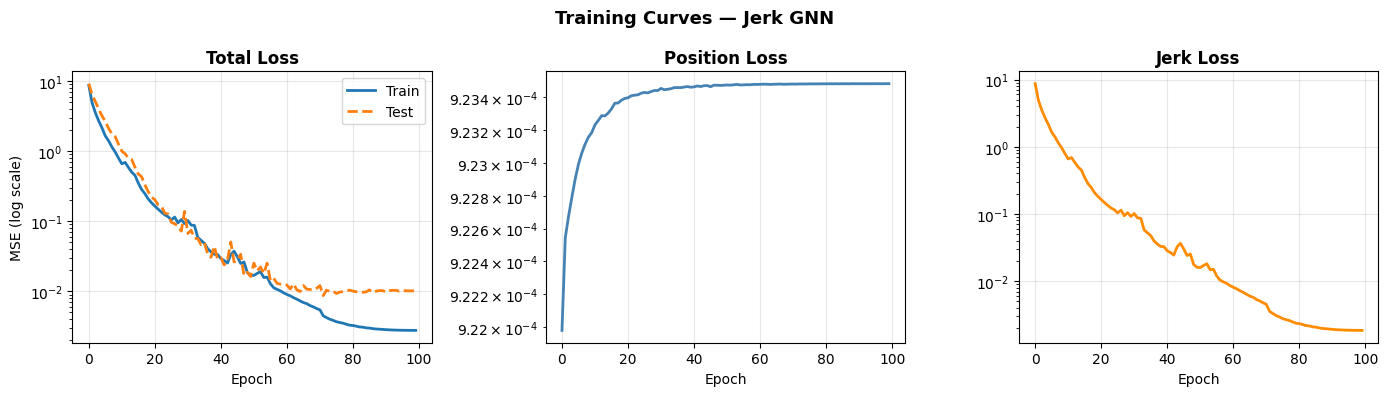

Final train loss: 2.77e-03  |  pos: 9.23e-04  |  jerk: 1.85e-03


In [67]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].semilogy(train_losses, label='Train', linewidth=2)
axes[0].semilogy(test_losses,  label='Test',  linewidth=2, linestyle='--')
axes[0].set_title('Total Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE (log scale)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].semilogy(pos_losses, color='steelblue', linewidth=2)
axes[1].set_title('Position Loss', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].grid(True, alpha=0.3)

axes[2].semilogy(jerk_losses, color='darkorange', linewidth=2)
axes[2].set_title('Jerk Loss', fontweight='bold')
axes[2].set_xlabel('Epoch'); axes[2].grid(True, alpha=0.3)

plt.suptitle('Training Curves — Jerk GNN', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/projectnb/depaqlab/bddepasq/spring-mass/png/curves-plot.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Final train loss: {train_losses[-1]:.2e}  |  pos: {pos_losses[-1]:.2e}  |  jerk: {jerk_losses[-1]:.2e}')

## 5. Rollout: Predicted vs True Dynamics

After training on single-step predictions, we evaluate the model **autoregressively**: starting from a true initial history window, the model's own predicted positions are fed back in at each step.

### Error accumulation mechanism

At each rollout step $t$:
1. $x_{\text{hist}}$ is drawn from the model's own previous predictions (not ground truth)
2. $v_t$, $a_t$ are estimated by finite differences applied to the predicted $x$ history
3. Any error in $x$ propagates to FD estimates of $v$ and $a$, which in turn corrupt the jerk estimate

This error accumulation is the main challenge for long-horizon rollouts. A well-trained model keeps errors small enough that the FD estimates remain accurate.

### What to look for
- **Position traces**: predicted trajectory (dashed) should closely track truth (solid) for at least several oscillation periods
- **Jerk traces**: even small position errors can cause jerk divergence since jerk is a 3rd derivative — correlation between predicted and true jerk is the tighter diagnostic

In [68]:
def rollout(model, system, x_traj, v_traj, a_traj, dt, history_len, device):
    """
    Autoregressively roll out the model from initial conditions.
    At each step, uses model's own previous predictions for x.
    Uses FD-estimated v and a (since we only observe x in real setting).
    """
    model.eval()
    T = x_traj.shape[0]
    n = system.n
    
    ei = system.edge_index.to(device)
    ea = system.edge_attr.to(device)
    
    x_pred_traj = np.zeros_like(x_traj)
    j_pred_traj = np.zeros_like(x_traj)
    j_true_traj = np.zeros_like(x_traj)
    
    # seed with true history
    x_pred_traj[:history_len] = x_traj[:history_len]
    
    x_window = x_traj[:history_len].copy()  # rolling window
    
    with torch.no_grad():
        for t in range(history_len, T - 1):
            x_hist_t = torch.tensor(
                x_window.T, dtype=torch.float32
            ).to(device)  # (n, history)
            a0 = torch.tensor(a_traj[t], dtype=torch.float32).to(device)
            v0 = torch.tensor(v_traj[t], dtype=torch.float32).to(device)
            
            x_next, _, _, j = model(x_hist_t, a0, v0, ei, ea, dt)
            
            x_pred_traj[t+1] = x_next.cpu().numpy()
            j_pred_traj[t]   = j.cpu().numpy()
            j_true_traj[t]   = system.analytic_jerk(v_traj[t])
            
            # advance window
            x_window = np.roll(x_window, -1, axis=0)
            x_window[-1] = x_pred_traj[t+1]
    
    return x_pred_traj, j_pred_traj, j_true_traj


# run on a fresh test trajectory
x_test, v_test, t_test = system.simulate(T=T_TEST, dt=DT)
_, a_test = finite_diff_va(x_test, DT)

x_pred, j_pred, j_true = rollout(
    model, system, x_test, v_test, a_test, DT, HISTORY, device
)

rmse = np.sqrt(np.mean((x_pred[HISTORY:] - x_test[HISTORY:])**2))
print(f'Rollout RMSE: {rmse:.4f}')

Rollout RMSE: 0.1578


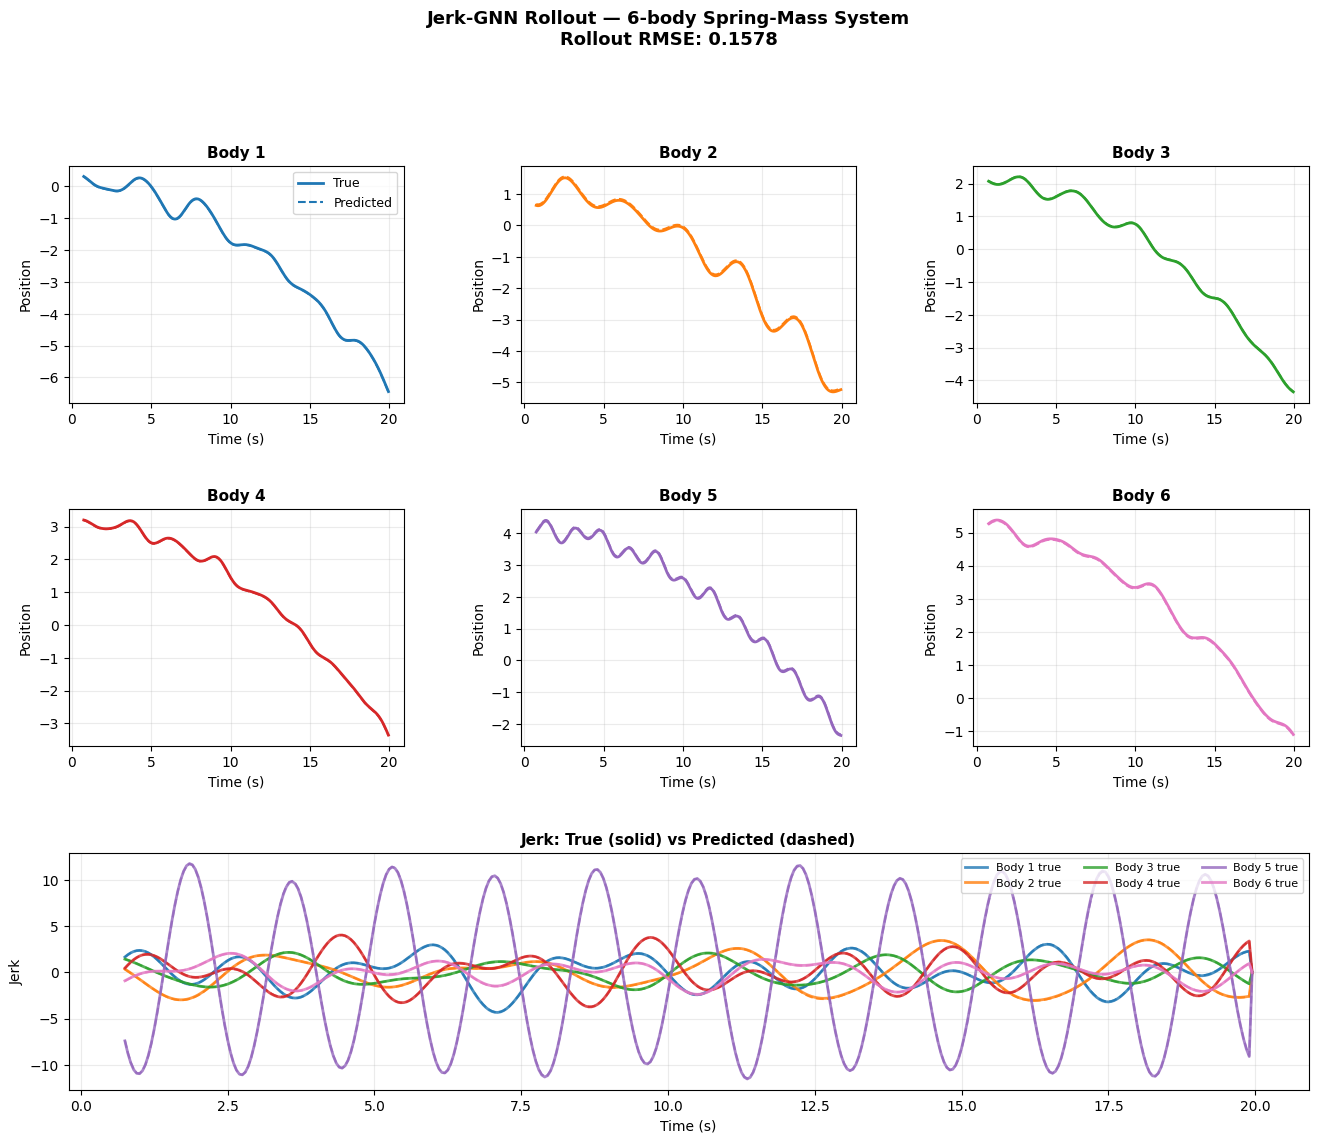

In [69]:
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(3, 3, hspace=0.45, wspace=0.35)

TRIM   = 10                        # skip first TRIM steps after seed to avoid FD transient
start  = HISTORY + TRIM
t_plot = t_test[start:]

# ── Position traces: one panel per body ──────────────────────────────────────
for i in range(6):
    row, col = divmod(i, 3)
    ax = fig.add_subplot(gs[row, col])
    ax.plot(t_plot, x_test[start:, i],  color=colors6[i],
            linewidth=2,   label='True')
    ax.plot(t_plot, x_pred[start:, i],  color=colors6[i],
            linewidth=1.5, linestyle='--', label='Predicted')
    ax.set_title(f'Body {i+1}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Position')
    if i == 0:
        ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25)

# ── Jerk comparison: all bodies ───────────────────────────────────────────────
ax_j = fig.add_subplot(gs[2, :])
for i in range(6):
    ax_j.plot(t_plot, j_true[start:, i], color=colors6[i],
              linewidth=2, alpha=0.8, label=f'Body {i+1} true')
    ax_j.plot(t_plot, j_pred[start:, i], color=colors6[i],
              linewidth=1.5, linestyle='--', alpha=0.8)

ax_j.set_title('Jerk: True (solid) vs Predicted (dashed)', fontsize=11, fontweight='bold')
ax_j.set_xlabel('Time (s)')
ax_j.set_ylabel('Jerk')
ax_j.legend(ncol=3, fontsize=8, loc='upper right')
ax_j.grid(True, alpha=0.25)

fig.suptitle(f'Jerk-GNN Rollout — 6-body Spring-Mass System\nRollout RMSE: {rmse:.4f}',
             fontsize=13, fontweight='bold', y=1.01)
plt.savefig('/projectnb/depaqlab/bddepasq/spring-mass/png/rollout-plot.png', dpi=150, bbox_inches='tight')
plt.show()

### Velocity traces and phase portraits

Velocity is estimated from predicted positions via finite differences. Because velocity is a derivative of position, velocity errors grow faster than position errors — this plot reveals whether the model maintains the correct oscillation frequency and amplitude over the full rollout.

**Phase portraits** ($x$ vs $v$) show the trajectory in state space. A well-performing model should trace closed or near-closed orbits that overlap with the true trajectory.

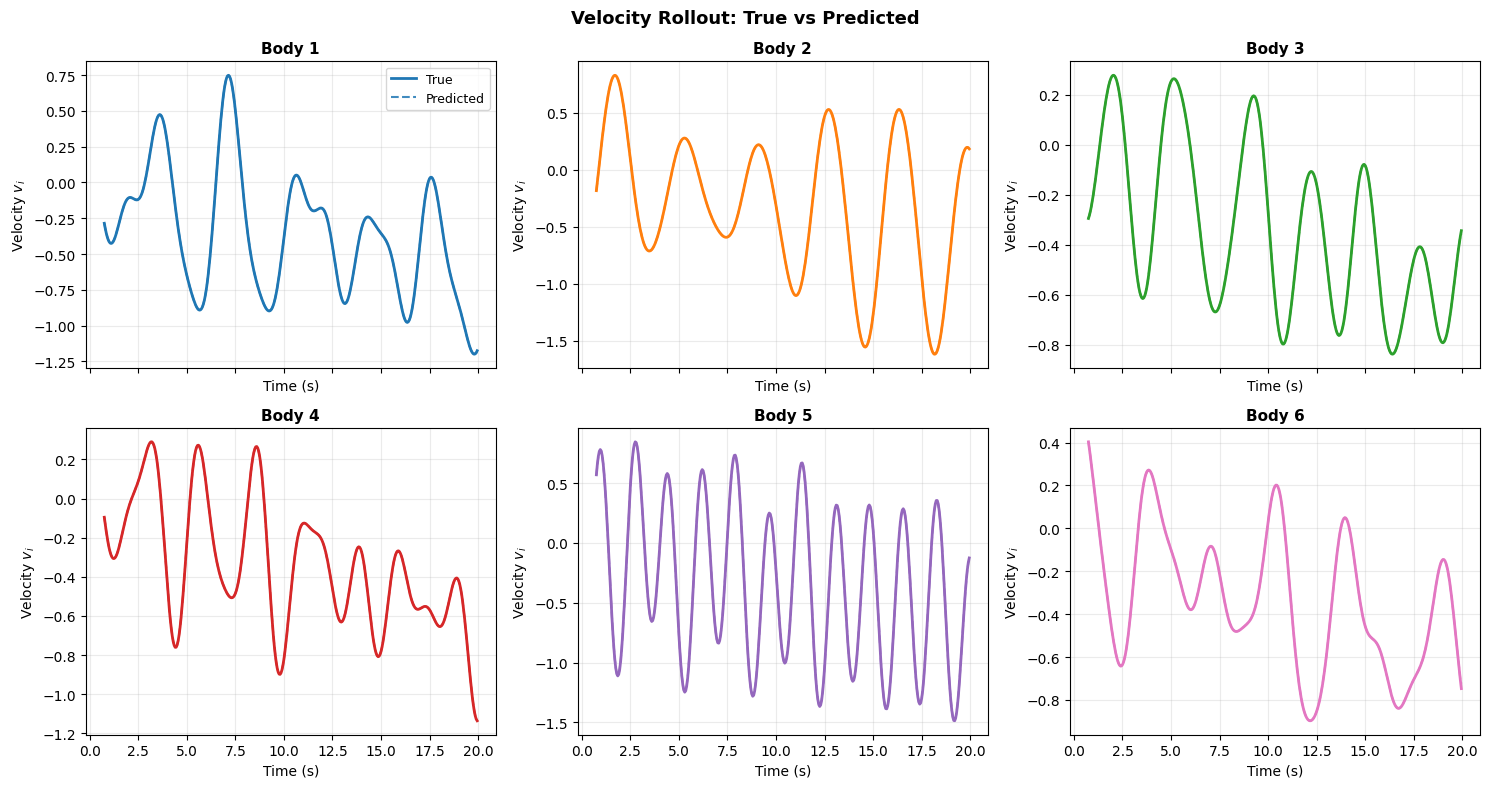

In [70]:
# Estimate velocity from predicted positions via FD
v_pred, _ = finite_diff_va(x_pred, DT)

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
axes = axes.flatten()

for i in range(6):
    ax = axes[i]
    ax.plot(t_plot, v_test[start:, i], color=colors6[i], linewidth=2, label='True')
    ax.plot(t_plot, v_pred[start:, i], color=colors6[i], linewidth=1.5,
            linestyle='--', alpha=0.85, label='Predicted')
    ax.set_title(f'Body {i+1}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Velocity $v_i$')
    ax.set_xlabel('Time (s)')
    if i == 0:
        ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25)

fig.suptitle('Velocity Rollout: True vs Predicted', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/projectnb/depaqlab/bddepasq/spring-mass/png/vel-plot.png', dpi=150, bbox_inches='tight')
plt.show()

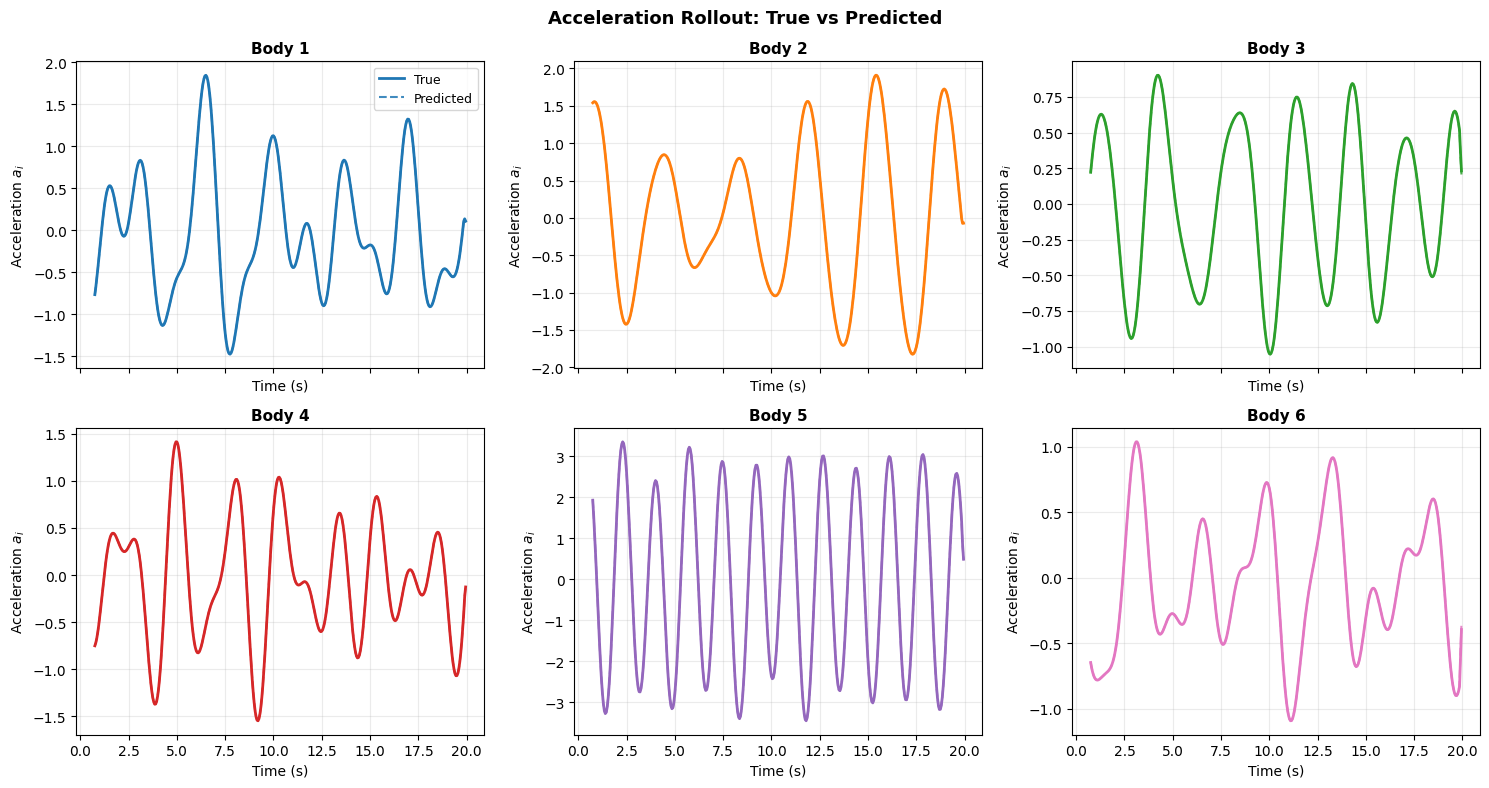

In [71]:
# Acceleration: FD from predicted velocity
_, a_pred = finite_diff_va(x_pred, DT)

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
axes = axes.flatten()

for i in range(6):
    ax = axes[i]
    ax.plot(t_plot, a_test[start:, i],  color=colors6[i], linewidth=2,   label='True')
    ax.plot(t_plot, a_pred[start:, i],  color=colors6[i], linewidth=1.5,
            linestyle='--', alpha=0.85, label='Predicted')
    ax.set_title(f'Body {i+1}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Acceleration $a_i$')
    ax.set_xlabel('Time (s)')
    if i == 0:
        ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25)

fig.suptitle('Acceleration Rollout: True vs Predicted', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/projectnb/depaqlab/bddepasq/spring-mass/png/km1rqe8vuz.png', dpi=150, bbox_inches='tight')
plt.show()

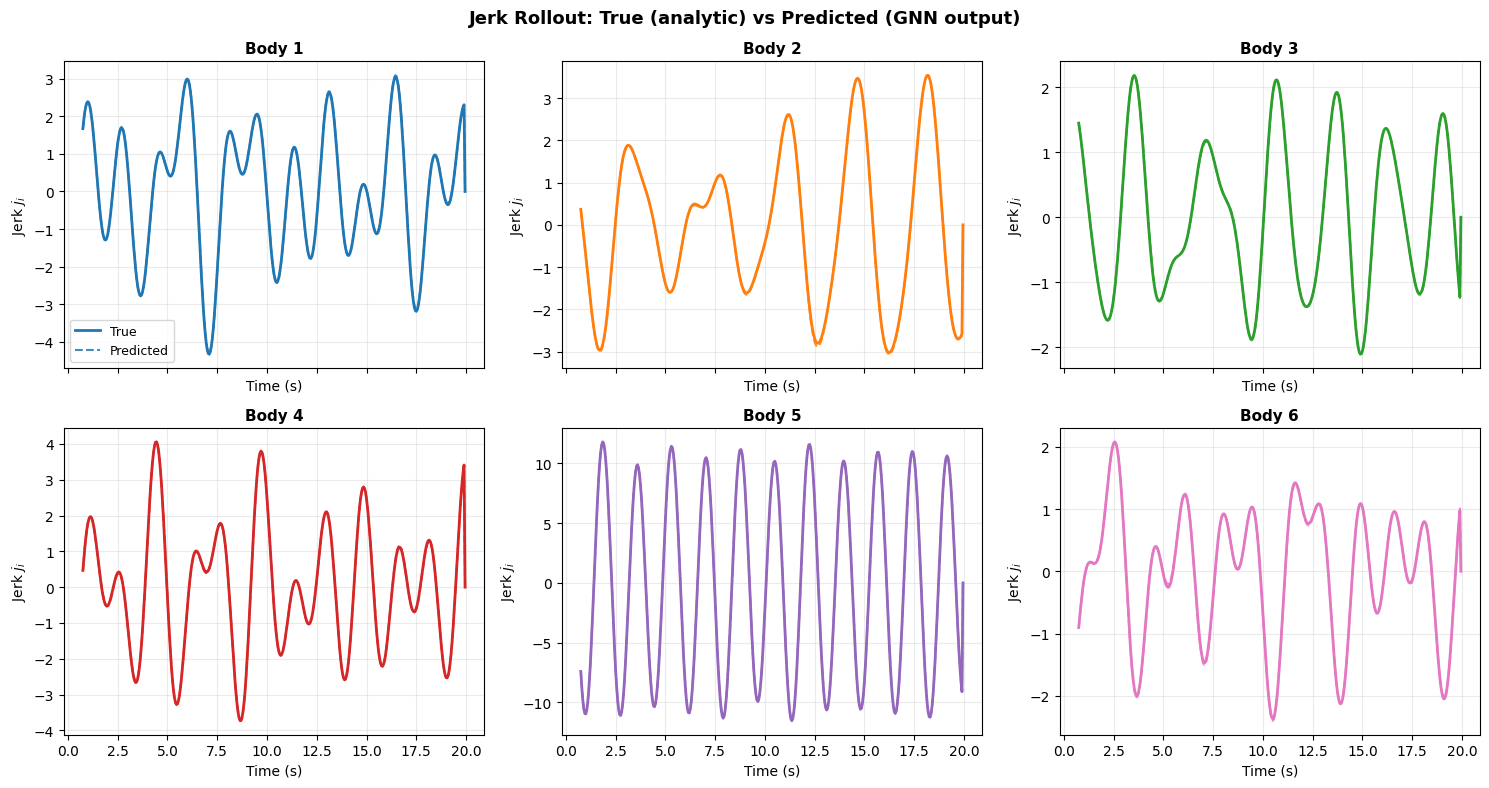

In [72]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
axes = axes.flatten()

for i in range(6):
    ax = axes[i]
    ax.plot(t_plot, j_true[start:, i], color=colors6[i], linewidth=2,   label='True')
    ax.plot(t_plot, j_pred[start:, i], color=colors6[i], linewidth=1.5,
            linestyle='--', alpha=0.85, label='Predicted')
    ax.set_title(f'Body {i+1}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Jerk $j_i$')
    ax.set_xlabel('Time (s)')
    if i == 0:
        ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25)

fig.suptitle('Jerk Rollout: True (analytic) vs Predicted (GNN output)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/projectnb/depaqlab/bddepasq/spring-mass/png/5uamdbo176e.png', dpi=150, bbox_inches='tight')
plt.show()

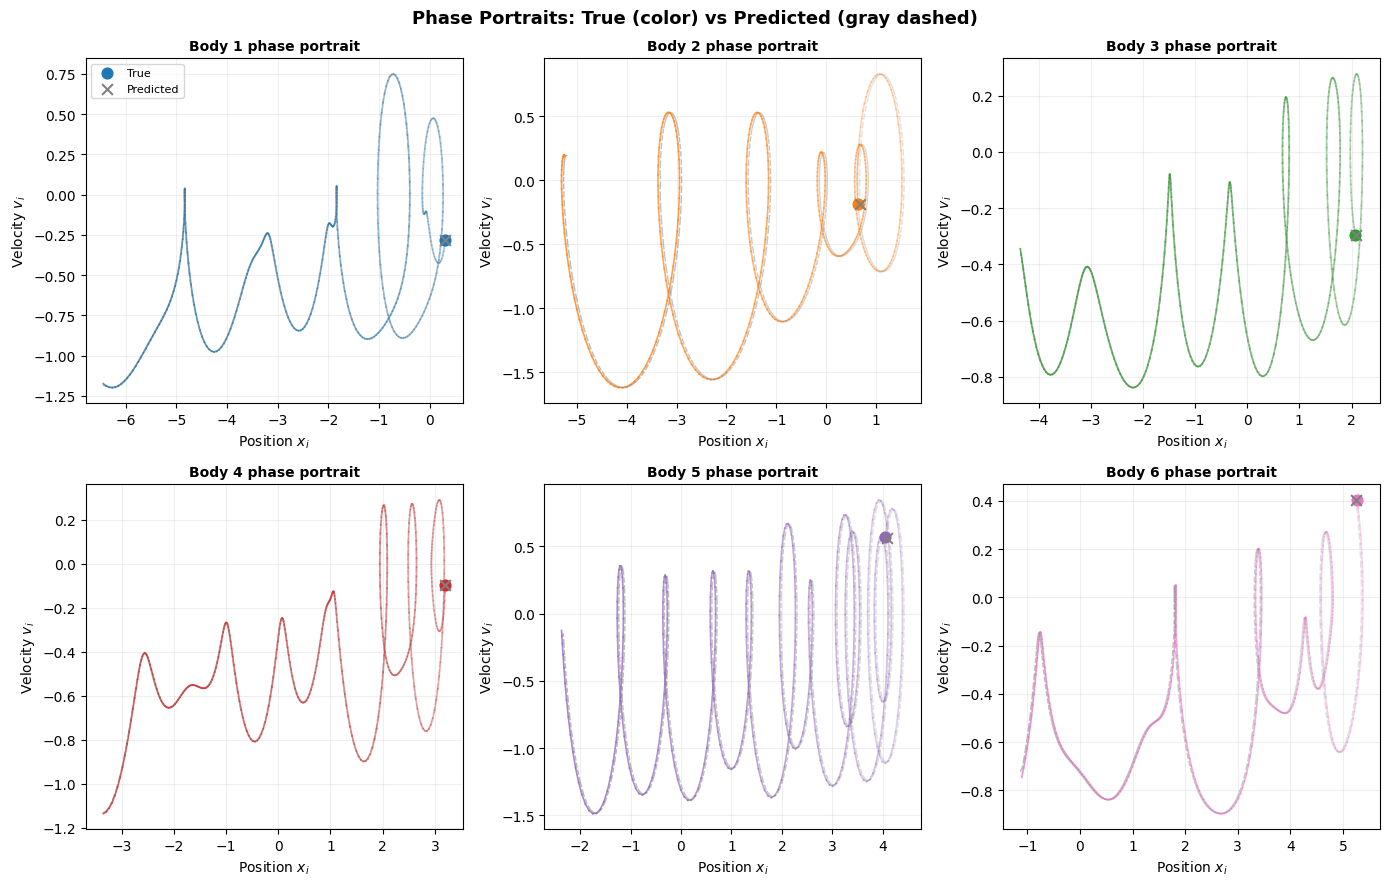

In [73]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

for i in range(6):
    ax = axes[i]
    # color by time to show trajectory direction
    n_pts = len(t_plot)
    for k in range(0, n_pts - 1, max(1, n_pts // 200)):
        alpha = 0.3 + 0.5 * k / n_pts
        ax.plot(x_test[start+k:start+k+2, i], v_test[start+k:start+k+2, i],
                color=colors6[i], alpha=alpha, linewidth=1.2)
        ax.plot(x_pred[start+k:start+k+2, i], v_pred[start+k:start+k+2, i],
                color='gray', alpha=alpha * 0.7, linewidth=1.0, linestyle='--')

    # label start points
    ax.scatter(x_test[start, i], v_test[start, i], color=colors6[i],
               s=60, zorder=5, marker='o', label='True')
    ax.scatter(x_pred[start, i], v_pred[start, i], color='gray',
               s=60, zorder=5, marker='x', label='Predicted')

    ax.set_title(f'Body {i+1} phase portrait', fontsize=10, fontweight='bold')
    ax.set_xlabel('Position $x_i$')
    ax.set_ylabel('Velocity $v_i$')
    if i == 0:
        ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)

fig.suptitle('Phase Portraits: True (color) vs Predicted (gray dashed)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/projectnb/depaqlab/bddepasq/spring-mass/png/phase-plot.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Jerk Correlation: Predicted vs Analytic

Each scatter plot shows predicted jerk $\hat{j}_i$ vs the analytically-computed ground-truth jerk $j_i^{\text{true}}$ at every time step of the rollout. The diagonal dashed line is perfect prediction.

- **Pearson $r$** close to 1 indicates the model correctly captures the sign and magnitude of jerk
- Systematic bias (points above/below diagonal) indicates the model over/under-estimates jerk amplitude
- Scatter around the diagonal reflects noise introduced by FD velocity estimation during rollout

Note: jerk quality will degrade later in the rollout as position errors compound into FD velocity errors.

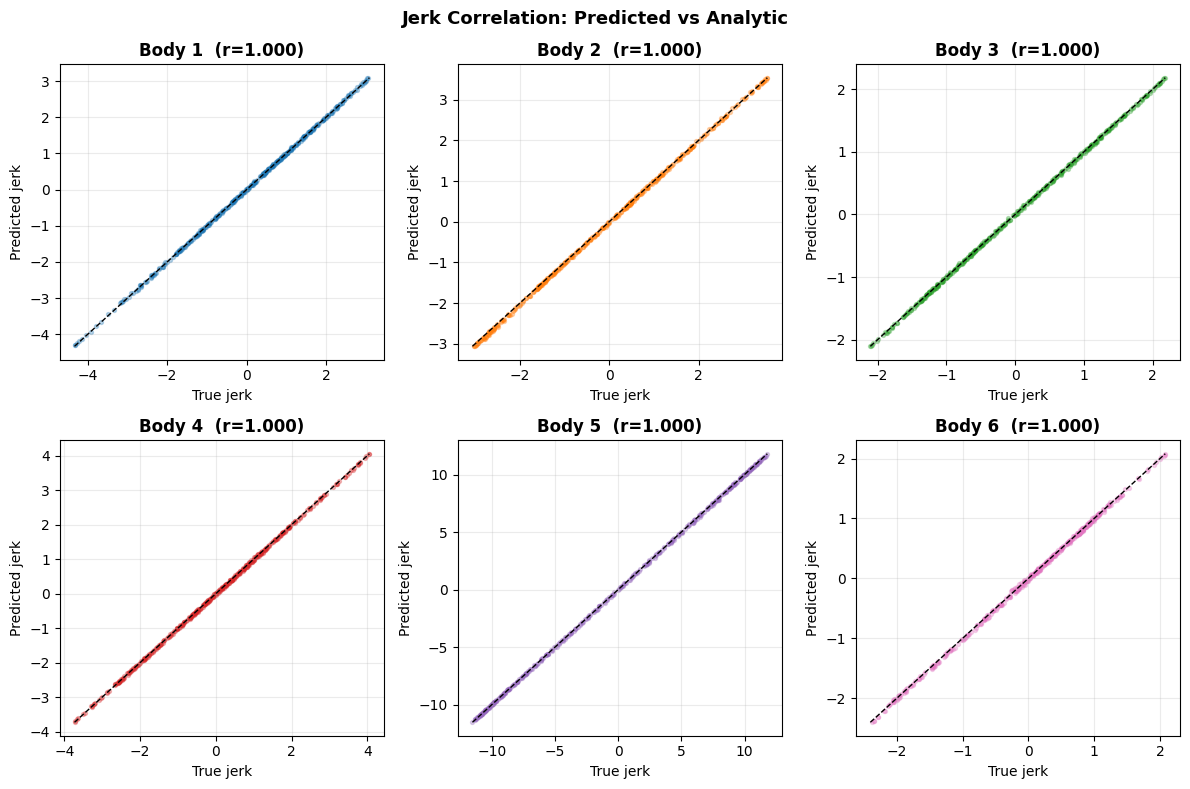

In [74]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i in range(6):
    jt = j_true[start:, i]
    jp = j_pred[start:, i]
    
    r = np.corrcoef(jt, jp)[0, 1]
    
    axes[i].scatter(jt, jp, alpha=0.3, s=8, color=colors6[i])
    lims = [min(jt.min(), jp.min()), max(jt.max(), jp.max())]
    axes[i].plot(lims, lims, 'k--', linewidth=1, label='ideal')
    axes[i].set_title(f'Body {i+1}  (r={r:.3f})', fontweight='bold')
    axes[i].set_xlabel('True jerk')
    axes[i].set_ylabel('Predicted jerk')
    axes[i].grid(True, alpha=0.25)

fig.suptitle('Jerk Correlation: Predicted vs Analytic', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/projectnb/depaqlab/bddepasq/spring-mass/png/jerk-corr-plot.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Error Over Time

### Mean RMSE across all bodies

These curves show how prediction error evolves over the rollout horizon:

- **Position RMSE**: direct measure of trajectory divergence; should stay near zero early and grow gradually
- **Jerk RMSE**: sensitive to high-frequency errors; may spike even when position error is still small

### Per-body breakdown

Below we also show position error per individual body to identify which bodies are harder to predict. Bodies with smaller masses or more spring connections tend to exhibit higher-frequency dynamics and may accumulate error faster.

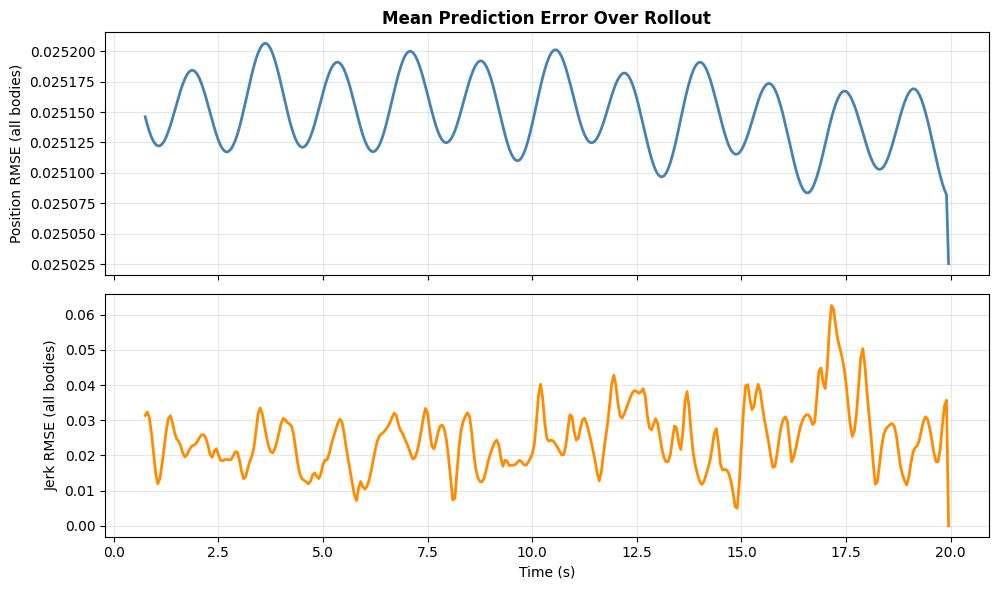

In [75]:
pos_err  = np.sqrt(((x_pred[start:] - x_test[start:])**2).mean(axis=1))
jerk_err = np.sqrt(((j_pred[start:] - j_true[start:])**2).mean(axis=1))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax1.plot(t_plot, pos_err, color='steelblue', linewidth=2)
ax1.set_ylabel('Position RMSE (all bodies)')
ax1.set_title('Mean Prediction Error Over Rollout', fontweight='bold')
ax1.grid(True, alpha=0.3)

ax2.plot(t_plot, jerk_err, color='darkorange', linewidth=2)
ax2.set_ylabel('Jerk RMSE (all bodies)')
ax2.set_xlabel('Time (s)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/projectnb/depaqlab/bddepasq/spring-mass/png/error-plot.png', dpi=150, bbox_inches='tight')
plt.show()

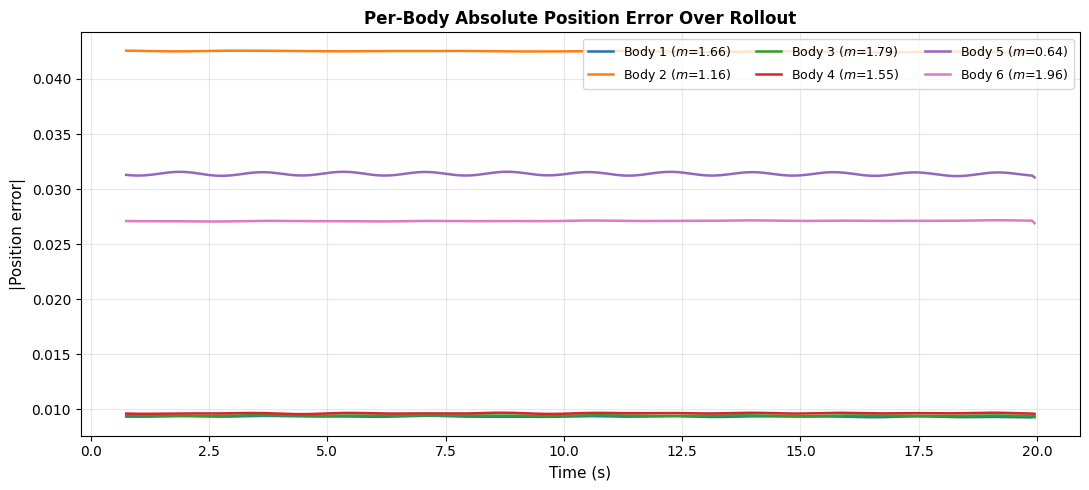


Final-step position error per body:
  Body 1 (m=1.66): 0.0094
  Body 2 (m=1.16): 0.0425
  Body 3 (m=1.79): 0.0093
  Body 4 (m=1.55): 0.0096
  Body 5 (m=0.64): 0.0311
  Body 6 (m=1.96): 0.0269


In [76]:
# Per-body absolute position error over time
per_body_err = np.abs(x_pred[start:] - x_test[start:])  # (T, n)

fig, ax = plt.subplots(figsize=(11, 5))
for i in range(6):
    ax.plot(t_plot, per_body_err[:, i], color=colors6[i], linewidth=1.8,
            label=f'Body {i+1} ($m$={system.masses[i]:.2f})')

ax.set_xlabel('Time (s)', fontsize=11)
ax.set_ylabel('|Position error|', fontsize=11)
ax.set_title('Per-Body Absolute Position Error Over Rollout', fontsize=12, fontweight='bold')
ax.legend(ncol=3, fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/projectnb/depaqlab/bddepasq/spring-mass/png/perbody-plot.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print('\nFinal-step position error per body:')
for i in range(6):
    print(f'  Body {i+1} (m={system.masses[i]:.2f}): {per_body_err[-1, i]:.4f}')

## 8. Energy Conservation

The spring-mass system is conservative: total mechanical energy $E = KE + PE$ should be constant in the absence of damping.

$$KE(t) = \sum_i \tfrac{1}{2} m_i v_i^2, \qquad PE(t) = \sum_{i < j} \tfrac{1}{2} k_{ij}\bigl[(x_j - x_i) - \text{sgn}(j-i)\,\ell_{ij}\bigr]^2$$

Energy conservation is **not enforced** by the architecture — the model is free to inject or dissipate energy. Monitoring energy drift is therefore a diagnostic for systematic model error:

- **Upward drift**: model is injecting energy → unstable long-term rollout
- **Downward drift**: model is dissipating energy → artificially damped oscillations
- **Flat**: model approximately respects the conservative structure

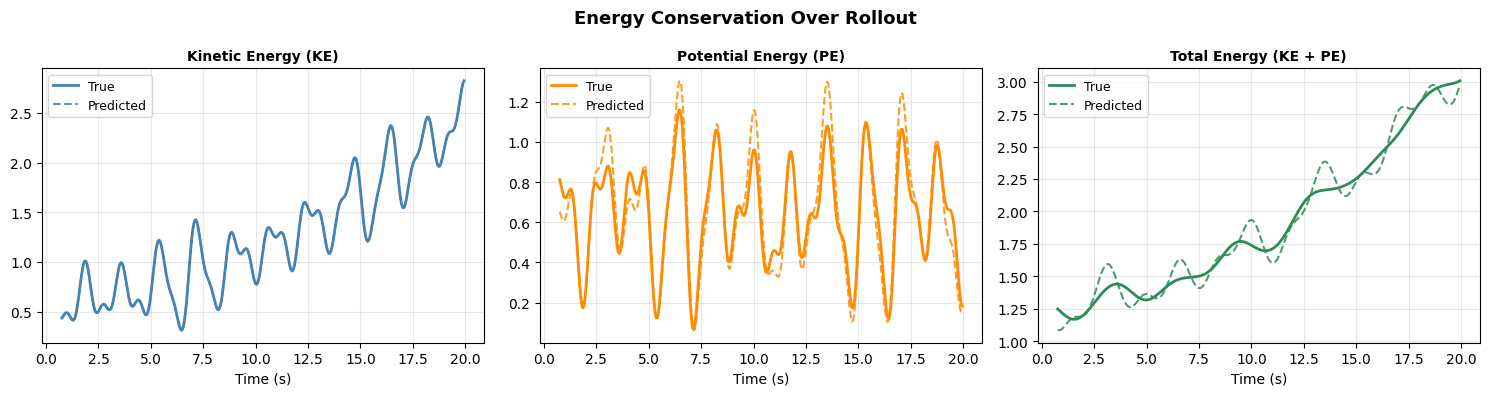

True energy (mean ± std): 1.902 ± 0.5527
Pred energy (mean ± std): 1.911 ± 0.5560
Relative energy drift over rollout: +151.408%


In [77]:
def compute_energy(x_traj, v_traj, system):
    """Compute KE, PE, and total energy along a trajectory."""
    T = x_traj.shape[0]
    KE = np.zeros(T)
    PE = np.zeros(T)
    for t in range(T):
        KE[t] = 0.5 * np.sum(system.masses * v_traj[t]**2)
        for i in range(system.n):
            for j in range(i + 1, system.n):
                if system.K[i, j] > 0:
                    disp = (x_traj[t, j] - x_traj[t, i]) - np.sign(j - i) * system.L[i, j]
                    PE[t] += 0.5 * system.K[i, j] * disp**2
    return KE, PE, KE + PE


KE_true, PE_true, E_true = compute_energy(x_test[start:], v_test[start:], system)
KE_pred, PE_pred, E_pred = compute_energy(x_pred[start:], v_pred[start:], system)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

labels = ['Kinetic Energy (KE)', 'Potential Energy (PE)', 'Total Energy (KE + PE)']
true_vals = [KE_true, PE_true, E_true]
pred_vals = [KE_pred, PE_pred, E_pred]
colors_ep = ['steelblue', 'darkorange', 'seagreen']

for ax, label, tv, pv, c in zip(axes, labels, true_vals, pred_vals, colors_ep):
    ax.plot(t_plot, tv, color=c, linewidth=2, label='True')
    ax.plot(t_plot, pv, color=c, linewidth=1.5, linestyle='--', alpha=0.85, label='Predicted')
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xlabel('Time (s)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle('Energy Conservation Over Rollout', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/projectnb/depaqlab/bddepasq/spring-mass/png/energy-plot.png', dpi=150, bbox_inches='tight')
plt.show()

energy_drift = (E_pred[-1] - E_pred[0]) / (E_true[0] + 1e-10)
print(f'True energy (mean ± std): {E_true.mean():.3f} ± {E_true.std():.4f}')
print(f'Pred energy (mean ± std): {E_pred.mean():.3f} ± {E_pred.std():.4f}')
print(f'Relative energy drift over rollout: {energy_drift:+.3%}')